In [134]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report,precision_score,recall_score,confusion_matrix,f1_score,roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Part 1

In [135]:
df = pd.read_csv('train.csv')
print(df.shape)
print(df.describe())

(891, 12)
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


# Part 2,3

Test accuracy: 0.9210526315789473
Precision (weighted): 0.9213790258116088
Recall (weighted): 0.9210526315789473
F1-score (weighted): 0.920230776506195
ROC-AUC: 0.9728185595567868
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       266
           1       0.93      0.85      0.89       152

    accuracy                           0.92       418
   macro avg       0.92      0.91      0.91       418
weighted avg       0.92      0.92      0.92       418



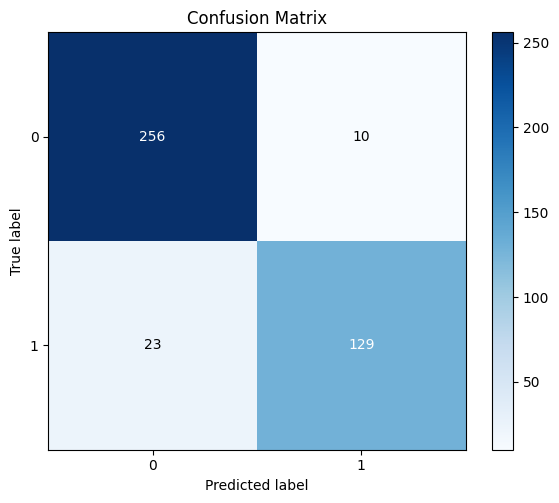

In [136]:
X = df.drop(columns=['Survived','PassengerId','Name','Ticket','Cabin'])
y = df['Survived']


categorical_cols = ['Sex','Embarked']
numeric_cols = [col for col in X.columns if col not in categorical_cols]


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200,max_depth=6))
])

pipeline.fit(X,y)
test = pd.read_csv('test.csv')
X_test = test.drop(columns=['PassengerId','Name','Cabin','Ticket'])
y_test = pd.read_csv('gender_submission.csv')['Survived']



# Printing the scores and plotting some info
y_pred = pipeline.predict(X_test)
print("Test accuracy:", pipeline.score(X_test, y_test))

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision (weighted):", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall (weighted):", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1-score (weighted):", f1)

y_proba = pipeline.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba[:, 1])
print("ROC-AUC:", roc_auc)

cm = confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(cm))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()



# Part 4

Test accuracy: 0.8444976076555024
Precision (weighted): 0.8436013117088499
Recall (weighted): 0.8444976076555024
F1-score (weighted): 0.843921360802585
ROC-AUC: 0.8899386624455876
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       266
           1       0.80      0.77      0.78       152

    accuracy                           0.84       418
   macro avg       0.83      0.83      0.83       418
weighted avg       0.84      0.84      0.84       418



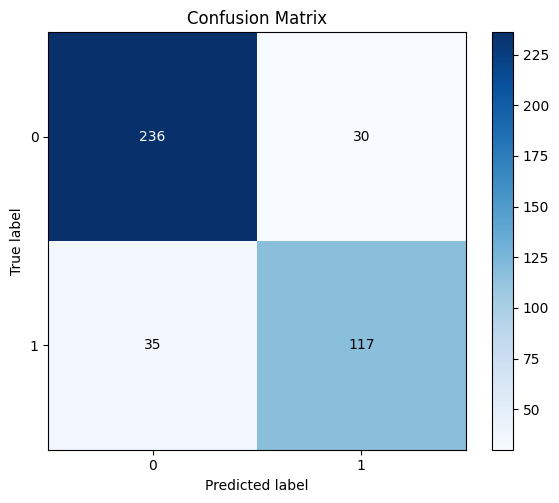

In [137]:
preprocessor = ColumnTransformer(
    transformers=[
    ('num', StandardScaler(),numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ]
)
pipeline= Pipeline([
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingClassifier())
])




# Printing the scores and plotting some info
pipeline.fit(X,y)
y_pred = pipeline.predict(X_test)
print("Test accuracy:", pipeline.score(X_test, y_test))

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision (weighted):", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall (weighted):", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1-score (weighted):", f1)

y_proba = pipeline.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba[:, 1])
print("ROC-AUC:", roc_auc)

cm = confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(cm))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()